'''
## **Assignment 8: Supervised Learning Classification**

## ** Bank Marketing Classification Using the UCI Machine Learning Repository ** 

This dataset contains information about bank customers and their interactions with a bank's marketing campaigns. The objective is to predict whether a customer will subscribe to a term deposit. 

In this notebook, you'll follow the machine learning process to build a classification model using the "Bank Marketing" dataset from the UCI Machine Learning Repository. The classification models will include Support Vector Machines, Random Forests and k-Nearest Neighbor classifiers.

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction

'''
'''
Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
                                
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   
   5 - default: has credit in default? (binary: "yes","no")
   
   6 - balance: average yearly balance, in euros (numeric) 
   
   7 - housing: has housing loan? (binary: "yes","no")
   
   8 - loan: has personal loan? (binary: "yes","no")
   
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
   
  10 - day: last contact day of the month (numeric)
  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
  

  Output variable (desired target):
  
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")
  
'''

In [48]:
# 1. Import the relevant libraries with their aliases

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score)


In [50]:
# 2. --- Data Collection and Loading ---

# Load dataset and convert to DataFrame:

df = pd.read_csv("bank-full.csv", sep=";")

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Check the features and target variable. Identify which is continuous and categorical if applicable.
print(df.shape)

print(df.info())

print(df.describe())

(45211, 17)
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
None
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  

In [44]:
'''
The dataset contains 45,211 observations and 17 attributes. There are 16 independent variables and 1 target variable. 
Among the 16 independent variables, 7 are numerical and 9 are categorical.

The target variable, y, indicates whether the client subscribed to a term deposit. 
It is a binary categorical variable with two possible values: "yes" and "no".

Since the target variable is categorical, this dataset is suitable for supervised learning classification 
using Support Vector Machines (SVM), Random Forests, and k-Nearest Neighbors (KNN) classifiers.

'''

'\nThe target variable (MEDV) is numerical, so this dataset is suitable for a regression model.\n\n\nThe maximum values of variables such as the crime rate by town (CRIM) and \nthe proportion of residential land zoned for large lots (ZN) are much higher than their means and quartiles, \nsuggesting that these variables may contain outliers.\n'

In [ ]:
#3. Exploratory Data Analysis (EDA)

In [14]:
# handle inconsistencies in the dataset

negative_balance = (df['balance'] < 0).sum()
print("Number of negative balance",negative_balance)

pdays_minus_one = (df['pdays'] == -1).sum()
print("Number of pdays values equal to -1:", pdays_minus_one)


Number of negative balance 3766
Number of pdays values equal to -1: 36954


In [ ]:
'''
The balance variable contains 3,766 negative values, which  represent clients with negative account balances or overdrafts. 
The pdays variable also contains 36,954 observations with -1 value, which indicates that the client was not previously contacted during an earlier campaign.

Some categorical variables contain the value "unknown", which indicates that the information was unavailable

'''


In [5]:
# Missing values

print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [6]:
'''
There are no missing values.
'''

'\nThere are no missing values.\n'

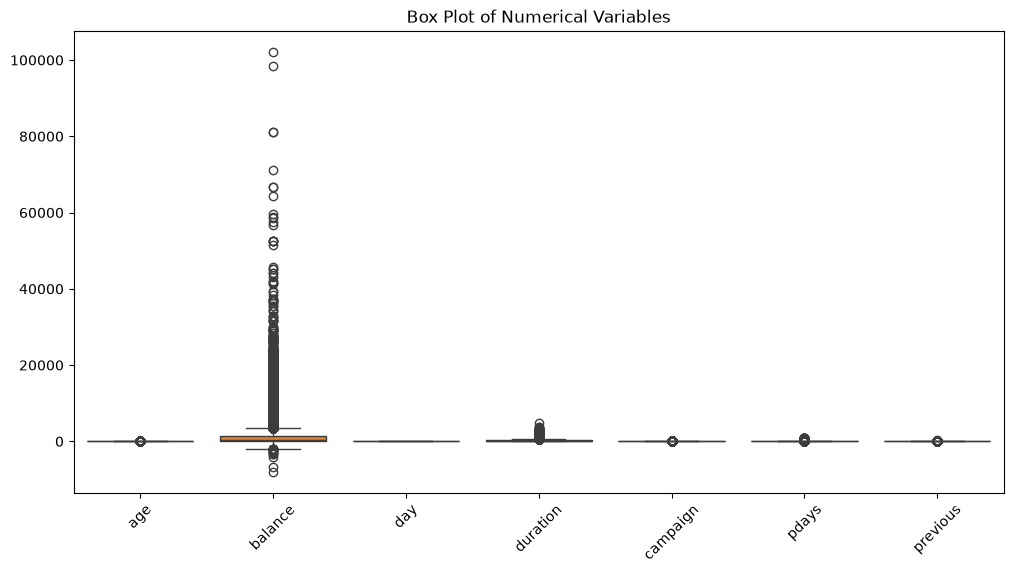

In [9]:
# Checking outliers using Box plot

# Selecting numerical variables
numeric_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Creating box plots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_vars])

plt.title('Box Plot of Numerical Variables')
plt.xticks(rotation=45)
plt.show()


In [24]:
# Handle Missing values
numeric_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

for col in numeric_vars:
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].map(
        lambda x: Q1 if x < lower_bound else Q3 if x > upper_bound else x
    )

In [11]:
df[numeric_vars].describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1216.623366,15.806419,254.823118,2.636615,40.072416,0.451306
std,10.618762,2036.083439,8.322476,239.103473,2.387328,99.456385,1.156036
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,14657.000000,31.000000,1823.000000,18.000000,792.000000,7.000000


In [25]:
# Visualize the data. Creating correlation matrix or percentage plots to see the relationship between independent features and the target variable.

# Convert target variable into numerical form
df['y_binary'] = df['y'].map({'no': 0, 'yes': 1})

# Select numerical variables
numeric_vars.append('y_binary')

print(numeric_vars)

print(df.head())

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y_binary']
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no   2143.0     yes   no   
1   44    technician   single  secondary      no     29.0     yes   no   
2   33  entrepreneur  married  secondary      no      2.0     yes  yes   
3   47   blue-collar  married    unknown      no   1506.0     yes   no   
4   33       unknown   single    unknown      no      1.0      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  \
0  unknown    5   may     261.0       1.0   -1.0       0.0  unknown  no   
1  unknown    5   may     151.0       1.0   -1.0       0.0  unknown  no   
2  unknown    5   may      76.0       1.0   -1.0       0.0  unknown  no   
3  unknown    5   may      92.0       1.0   -1.0       0.0  unknown  no   
4  unknown    5   may     198.0       1.0   -1.0       0.0  unknown  no   

   y_binary  
0      

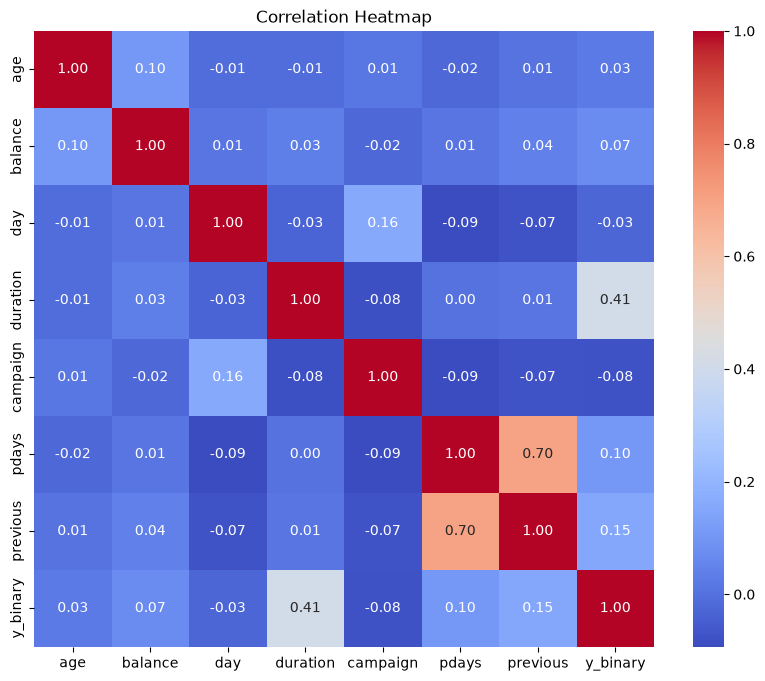

In [27]:
# Select numerical variables
numeric_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
numeric_vars.append('y_binary')

# Calculate correlation matrix
correlation_matrix = df[numeric_vars].corr()

# Calculate the correlation matrix
heatmap = df[numeric_vars].corr()

# Display the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
'''
Duration has the strongest positive correlation (0.4) with the target variable, 
indicating that longer call durations are associated with a higher likelihood of clients subscribing to a term deposit.

There is a strong positive relationship (0.7) between pdays and previous, 
suggesting that these two variables tend to increase together.
'''

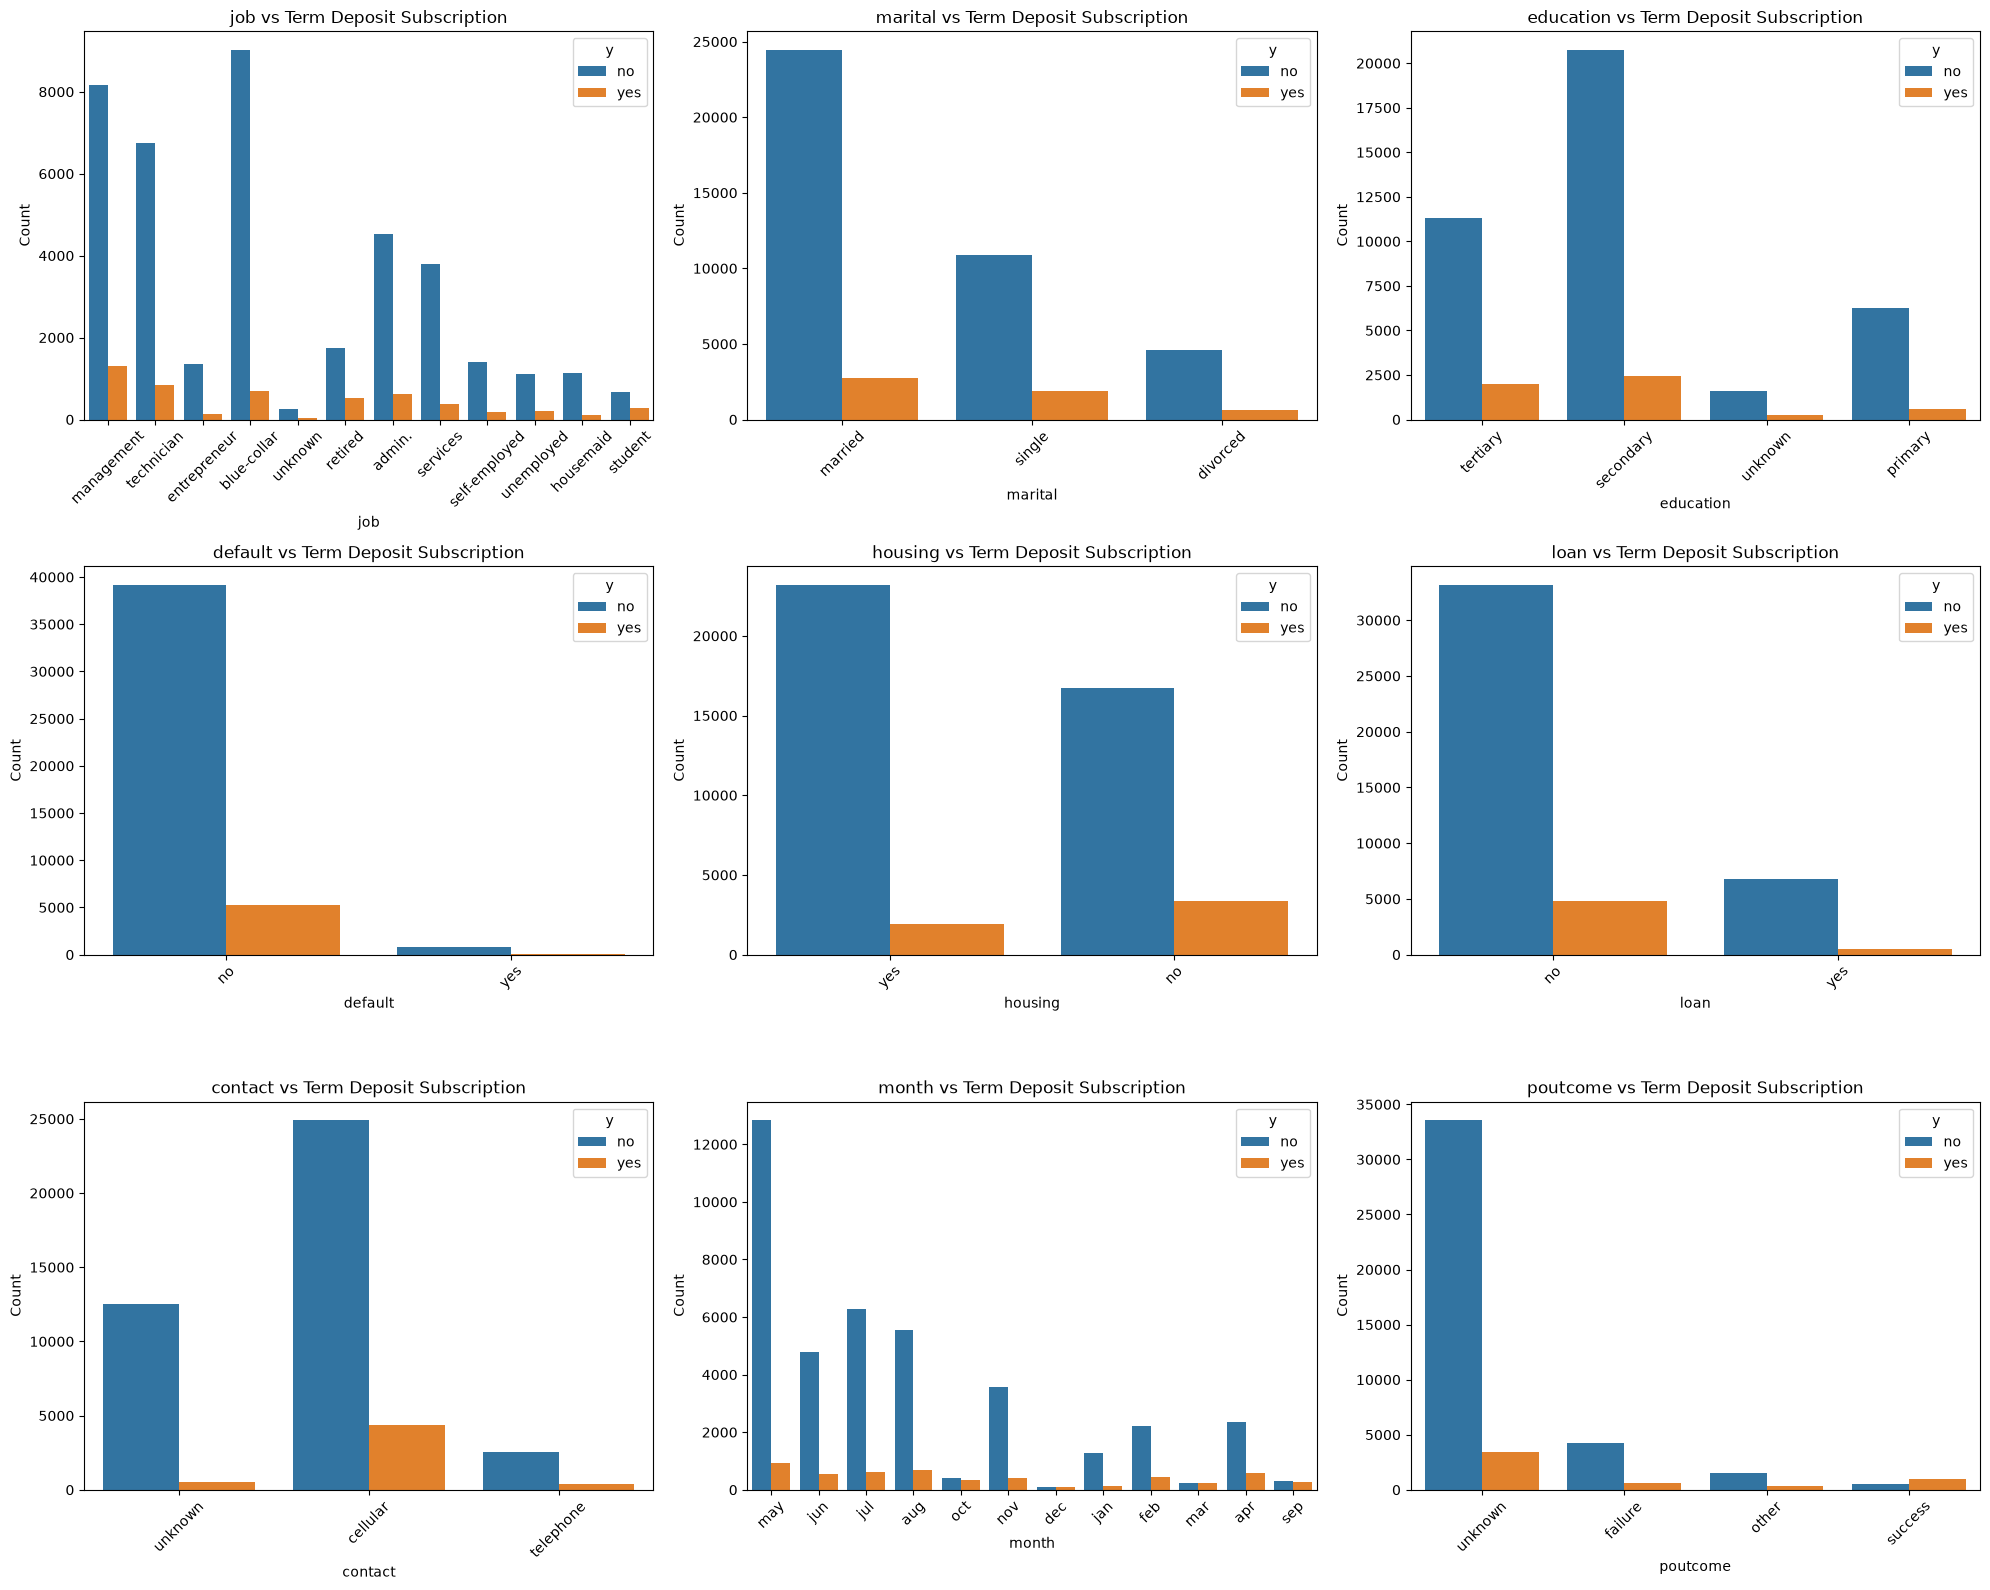

In [28]:
# exploring categorical variables

categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(20, 16))

for ax, col in zip(axes.flatten(), categorical_vars):
    sns.countplot(data=df, x=col, hue='y', ax=ax)
    
    ax.set_title(f'{col} vs Term Deposit Subscription')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
'''
According to these plots,

The categorical variables show several relationships with the target variable. 
Clients with no previous default are more frequently associated with subscribing to a term deposit. 
Similarly, clients without a housing loan and those without a personal loan appear more likely to subscribe.

Similarly, clients contacted through cellular communication (contact) being more frequently associated with a positive subscription outcome.

For marital, married clients represent a larger proportion of subscribers compared with single and divorced clients.

'''

In [29]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1.0,-1.0,0.0,unknown,no,0
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1.0,-1.0,0.0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1.0,-1.0,0.0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1.0,-1.0,0.0,unknown,no,0
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1.0,-1.0,0.0,unknown,no,0


In [32]:
# 3. --- ML Model Training ---

# TODO: Split the dataset into training and testing sets.
X = df.drop(columns=['y', 'y_binary'])
y = df['y']

In [35]:
# Define numerical and categorical variables
numeric_vars = [
    'age', 'balance', 'day', 'duration',
    'campaign', 'pdays', 'previous'
]

categorical_vars = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month', 'poutcome'
]

In [36]:
# Encoding and scaler
transform = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_vars)
    ]
)

In [38]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = transform.fit_transform(X_train)
X_test = transform.transform(X_test)

In [49]:
# Train the model on the training data.
    
# Model 1 : Support Vector Machines (SVM)

svm_model = CalibratedClassifierCV( SVC(kernel='rbf', random_state=42), ensemble=False)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [51]:
# Model 2: Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [52]:
# KNN

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

In [53]:
# 4.--- Model Evaluation ---

# Getting probability scores for calculating ROC-AUC

# Calculating probalility of each model
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]


In [54]:
# Calculate ROC-AUC
y_test_binary = (y_test == 'yes').astype(int)

roc_auc_svm = roc_auc_score(y_test_binary, y_prob_svm)
roc_auc_rf = roc_auc_score(y_test_binary, y_prob_rf)
roc_auc_knn = roc_auc_score(y_test_binary, y_prob_knn)


In [55]:
# Comparison table 
results = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm, pos_label='yes'),
        precision_score(y_test, y_pred_rf, pos_label='yes'),
        precision_score(y_test, y_pred_knn, pos_label='yes')
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm, pos_label='yes'),
        recall_score(y_test, y_pred_rf, pos_label='yes'),
        recall_score(y_test, y_pred_knn, pos_label='yes')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_svm, pos_label='yes'),
        f1_score(y_test, y_pred_rf, pos_label='yes'),
        f1_score(y_test, y_pred_knn, pos_label='yes')
    ],
    'ROC-AUC': [
        roc_auc_svm,
        roc_auc_rf,
        roc_auc_knn
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.905562,0.680212,0.363894,0.474138,0.900100
1,Random Forest,0.906889,0.668224,0.405482,0.504706,0.928193
2,KNN,0.897932,0.612688,0.346881,0.442969,0.825470


In [ ]:
'''
Random Forest is the best-performing model overall. 

Random Forest has the highest accuracy, recall, F1 Score, and ROC-AUC. 
In particular, its ROC-AUC of 0.9282 indicates a strong ability to distinguish between customers 
who subscribed to a term deposit and those who did not.

Recall (below 41%). This means that despite their high accuracy, they fail to identify many of 
the customers who actually subscribe. This is likely related to the class imbalance 
in the dataset, where no (88.3%) is much more common than yes (11.7%).

'''

In [ ]:
## Deployment and Monitoring

## Model Deployment
The Random Forest model performed best. It can be deployed in production.
    
The model can be deployed as a web API using a framework such as Flask or FastAPI.

## Monitoring
The process can be designed in five steps:
    
- Send the customer's information to the application
- Apply the required preprocessing steps
- Send the processed data to the Random Forest model
- Calculate the predicted probability of subscribing to a term deposit
- Return the predicted class (yes or no).

## Potential Deployment Issues
Several issues can occur after deployment:

Data quality: Customer data may contain errors or unexpected values
Data format: New data must have the same format as the training data
Model updates: The model may need to be retrained with new data to maintain good performance.



In [ ]:
#